# 07 - IEMOCAP Emotion2Vec-Guided Co-Attention Multi-Task SER

Notebook này hiện thực phần nâng cấp từ 06D theo roadmap mới:

- Dataset chính: **IEMOCAP**.
- Task 1: **emotion classification** với 4 class phổ biến: `angry`, `sad`, `neutral`, `happy_excited`.
- Task 2: **Arousal / Valence / Dominance regression** từ nhãn dimensional emotion của IEMOCAP.
- Split chính: **Leave-One-Session-Out 5-fold**.
- Split mở rộng: **Leave-One-Speaker-Out 10-fold**.
- Model: phát triển từ 06D, dùng `emotion2vec` làm representation trung tâm, acoustic branches hỗ trợ bằng co-attention/gated fusion.

Notebook có thể chạy theo từng mức:

1. Chỉ build metadata và split.
2. Trích xuất handcrafted acoustic features.
3. Nếu có `funasr/modelscope`, bật Emotion2Vec thật.
4. Train multi-task model và export metrics.

> Lưu ý: IEMOCAP official cần xin quyền truy cập. Notebook này giả định bạn đã có thư mục `IEMOCAP_full_release` trên máy hoặc đã chuẩn bị metadata CSV tương đương.


## Optimization notes\n
\n
Bản này chỉnh một số cấu hình để chạy 5-fold LOSO ổn định hơn: `LR=3e-4`, `DROPOUT=0.45`, `WEIGHT_DECAY=5e-4`, `LAMBDA_AVD=0.5`, `MAX_EPOCHS=35`, `PATIENCE=8`. Checkpoint được chọn theo score tổng hợp `0.45*UAR + 0.35*Macro-F1 + 0.20*CCC_mean`.\n

## 1. Cài thư viện

Nếu thiếu thư viện, mở comment dòng pip tương ứng. Emotion2Vec là optional vì cần `funasr` và model pretrained.


In [1]:
# !pip install numpy pandas librosa soundfile scikit-learn matplotlib seaborn tqdm
# !pip install torch
# Optional for real emotion2vec embeddings:
!pip install funasr modelscope


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 298.8/298.8 kB 19.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.7/89.7 kB 8.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.6/449.6 kB 27.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 926.2/926.2 kB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 111.6 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.5/155.5 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.5/99.5 kB 8.5 MB/s eta 0:00:00
  Created wheel for oss2: filename=oss2-2.19.1-py3-none-any.whl size=1240

## 2. Imports và cấu hình

Cell này đã được chỉnh để chạy được trên Kaggle:

- Nếu đang ở Kaggle, output sẽ lưu vào `/kaggle/working/07_iemocap_multitask_outputs`.
- Notebook tự dò IEMOCAP trong `/kaggle/input`.
- Nếu tự dò không đúng, sửa `IEMOCAP_ROOT` thủ công thành đường dẫn dataset trong Kaggle, ví dụ:

```python
IEMOCAP_ROOT = Path("/kaggle/input/iemocap/IEMOCAP_full_release")
```


In [2]:
import os
import re
import json
import time
import random
import warnings
import logging
import signal
import contextlib
import io
from pathlib import Path

import numpy as np
import pandas as pd
import librosa
import soundfile as sf
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
)
from sklearn.preprocessing import StandardScaler

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

warnings.filterwarnings("ignore")
logging.getLogger("funasr").setLevel(logging.ERROR)
logging.getLogger("modelscope").setLevel(logging.ERROR)
sns.set_theme(style="whitegrid")

SEED = int(os.getenv("SEED", "42"))
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

IS_KAGGLE = Path("/kaggle/working").exists()
PROJECT_ROOT = Path("/kaggle/working") if IS_KAGGLE else Path(r"D:\voice-presentation-feedback")
OUT_DIR = PROJECT_ROOT / "07_iemocap_multitask_outputs"
CACHE_DIR = OUT_DIR / "cache"
FIG_DIR = OUT_DIR / "figures"
REPORT_DIR = OUT_DIR / "reports"
for d in [OUT_DIR, CACHE_DIR, FIG_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

def find_iemocap_root():
    env_root = os.getenv("IEMOCAP_ROOT", "").strip()
    if env_root:
        return Path(env_root)

    candidates = []
    if IS_KAGGLE:
        kaggle_input = Path("/kaggle/input")
        if kaggle_input.exists():
            candidates.extend([p for p in kaggle_input.rglob("*") if p.is_dir() and p.name == "IEMOCAP_full_release"])
            candidates.extend([p for p in kaggle_input.rglob("*") if p.is_dir() and (p / "Session1" / "dialog" / "EmoEvaluation").exists()])
    candidates.extend([
        Path(r"D:\datasets\IEMOCAP_full_release"),
        Path(r"D:\IEMOCAP_full_release"),
        Path.cwd() / "IEMOCAP_full_release",
    ])

    for cand in candidates:
        if (cand / "Session1" / "dialog" / "EmoEvaluation").exists():
            return cand
    return Path("")


# Cấu hình đường dẫn IEMOCAP.
# Trên Kaggle, notebook tự tìm trong /kaggle/input.
# Nếu tự tìm sai, sửa dòng dưới thành path dataset của bạn.
IEMOCAP_ROOT = find_iemocap_root()


def find_iemocap_csv():
    env_csv = os.getenv("IEMOCAP_CSV", "").strip()
    if env_csv:
        return Path(env_csv)
    if IS_KAGGLE:
        candidates = [
            Path("/kaggle/input/iemocap-csv/iemocap.csv"),
            Path("/kaggle/input/iemocap_csv/iemocap.csv"),
            Path("/kaggle/input/iemocap-emotion-speech-database/iemocap_full_dataset.csv"),
        ]
        for cand in candidates:
            if cand.exists():
                return cand
        hits = list(Path("/kaggle/input").rglob("*iemocap*.csv"))
        if hits:
            return hits[0]
    return Path("")


def find_iemocap_raw_base():
    env_raw = os.getenv("IEMOCAP_RAW_BASE", "").strip()
    if env_raw:
        return Path(env_raw)
    if IS_KAGGLE:
        for hit in Path("/kaggle/input").rglob("IEMOCAP_full_release"):
            if hit.is_dir() and (hit / "Session1").exists():
                return hit.parent
        candidates = [
            Path("/kaggle/input/iemocapfullrelease"),
            Path("/kaggle/input/iemocap-full-release"),
            Path("/kaggle/input/iemocap-emotion-speech-database"),
            Path("/kaggle/input/iemocap"),
        ]
        for cand in candidates:
            if cand.exists():
                return cand
        for cand in Path("/kaggle/input").iterdir():
            if cand.is_dir():
                if (cand / "IEMOCAP_full_release").exists():
                    return cand
                if (cand / "Iemocap-full-release" / "IEMOCAP_full_release").exists():
                    return cand
                if any(cand.rglob("Session1")):
                    return cand
    return IEMOCAP_ROOT.parent if str(IEMOCAP_ROOT) else Path("")


IEMOCAP_CSV = find_iemocap_csv()
IEMOCAP_RAW_BASE = find_iemocap_raw_base()

# Nếu bạn đã có metadata CSV tự chuẩn bị, set path ở đây.
# CSV nên có: sample_id, filepath, session, speaker_id, emotion, EmoAct, EmoVal, EmoDom
IEMOCAP_METADATA_CSV = Path(os.getenv("IEMOCAP_METADATA_CSV", str(OUT_DIR / "iemocap_metadata.csv")))

TARGET_SR = 16_000
TARGET_DURATION = float(os.getenv("TARGET_DURATION", "4.0"))
TARGET_LENGTH = int(TARGET_SR * TARGET_DURATION)
N_FFT = 400
WIN_LENGTH = 400
HOP_LENGTH = 160
N_MFCC = 40
N_MELS = 96
MAX_FRAMES = int(1 + TARGET_LENGTH // HOP_LENGTH)

EMOTION_MAP = {
    "ang": "angry",
    "sad": "sad",
    "neu": "neutral",
    "hap": "happy_excited",
    "exc": "happy_excited",
}
COMMON_EMOTIONS = ["angry", "sad", "neutral", "happy_excited"]
LABEL_TO_ID = {label: i for i, label in enumerate(COMMON_EMOTIONS)}
ID_TO_LABEL = {i: label for label, i in LABEL_TO_ID.items()}

# IEMOCAP evaluation files commonly store dimensional labels in [valence, activation/arousal, dominance] order.
DIMENSION_ORDER_IN_EVAL = ["EmoVal", "EmoAct", "EmoDom"]
AVD_COLS = ["EmoAct", "EmoVal", "EmoDom"]

RUN_EMOTION2VEC = True
EMOTION2VEC_MODEL = os.getenv("EMOTION2VEC_MODEL", "iic/emotion2vec_base")
ALLOW_ZERO_E2V = os.getenv("ALLOW_ZERO_E2V", "1") == "1"
PARTIAL_CACHE_EVERY = int(os.getenv("PARTIAL_CACHE_EVERY", "25"))
E2V_TIMEOUT_SECONDS = int(os.getenv("E2V_TIMEOUT_SECONDS", "120"))
MAX_FEATURE_SAMPLES = int(os.getenv("MAX_FEATURE_SAMPLES", "0"))

BATCH_SIZE = int(os.getenv("BATCH_SIZE", "16"))
MAX_EPOCHS = int(os.getenv("MAX_EPOCHS", "35"))
PATIENCE = int(os.getenv("PATIENCE", "8"))
LR = float(os.getenv("LR", "3e-4"))
WEIGHT_DECAY = float(os.getenv("WEIGHT_DECAY", "5e-4"))
DROPOUT = float(os.getenv("DROPOUT", "0.45"))

LAMBDA_EMOTION = float(os.getenv("LAMBDA_EMOTION", "1.0"))
LAMBDA_AVD = float(os.getenv("LAMBDA_AVD", "0.5"))
SMOOTH_L1_ALPHA = float(os.getenv("SMOOTH_L1_ALPHA", "0.2"))

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)
print("IS_KAGGLE:", IS_KAGGLE)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUT_DIR:", OUT_DIR)
print("IEMOCAP_ROOT:", IEMOCAP_ROOT)
print("IEMOCAP_CSV:", IEMOCAP_CSV)
print("IEMOCAP_RAW_BASE:", IEMOCAP_RAW_BASE)
if IS_KAGGLE:
    print("Kaggle input folders:")
    for p in sorted(Path("/kaggle/input").iterdir()):
        if p.is_dir():
            print(" -", p)
print("RUN_EMOTION2VEC:", RUN_EMOTION2VEC)


DEVICE: cuda
IS_KAGGLE: True
PROJECT_ROOT: /kaggle/working
OUT_DIR: /kaggle/working/07_iemocap_multitask_outputs
IEMOCAP_ROOT: /kaggle/input/datasets/dejolilandry/iemocapfullrelease/IEMOCAP_full_release
IEMOCAP_CSV: /kaggle/input/datasets/samuelsamsudinng/iemocap-emotion-speech-database/iemocap_full_dataset.csv
IEMOCAP_RAW_BASE: /kaggle/input/datasets/dejolilandry/iemocapfullrelease
Kaggle input folders:
 - /kaggle/input/datasets
RUN_EMOTION2VEC: True


## 3. Build / load IEMOCAP metadata

Cell này hỗ trợ **hai kiểu dữ liệu Kaggle**:

### Kiểu A: CSV đã xử lý sẵn

Nếu có file:

```text
/kaggle/input/iemocap-csv/iemocap.csv
```

notebook sẽ ưu tiên đọc CSV này. CSV cần có các cột như trong notebook dataset tham khảo:

```text
session, emotion, valence, activation, dominance, wav_path
```

Sau đó notebook tự map:

```text
activation -> EmoAct
valence -> EmoVal
dominance -> EmoDom
hap/exc -> happy_excited
```

và tự dựng `filepath` audio từ `wav_path`.

### Kiểu B: Official IEMOCAP tree

Nếu không có CSV, notebook sẽ parse cấu trúc official IEMOCAP:

```text
IEMOCAP_full_release/
  Session1/
    dialog/EmoEvaluation/*.txt
    sentences/wav/<dialog_id>/<utterance_id>.wav
  ...
  Session5/
```

Mỗi dòng evaluation thường chứa:

```text
[start - end]    utterance_id    emotion    [valence, activation, dominance]
```

Notebook map `hap` và `exc` thành `happy_excited`, giống setup 4-class phổ biến trên IEMOCAP.


In [3]:
EVAL_LINE_RE = re.compile(
    r"^\[(?P<start>[\d.]+)\s*-\s*(?P<end>[\d.]+)\]\s+"
    r"(?P<utt>\S+)\s+"
    r"(?P<emo>\S+)\s+"
    r"\[(?P<dims>[^\]]+)\]"
)


def infer_session_from_utt(utt_id: str) -> str:
    # Example: Ses01F_impro01_F000 -> Session1
    m = re.match(r"Ses0?(\d)", utt_id)
    if not m:
        return "unknown"
    return f"Session{int(m.group(1))}"


def infer_speaker_from_utt(utt_id: str) -> str:
    # Example speaker prefix: Ses01F or Ses01M from utterance id.
    m = re.match(r"(Ses0?\d[FM])", utt_id)
    return m.group(1) if m else "unknown"


def resolve_iemocap_wav(root: Path, utt_id: str) -> Path:
    session = infer_session_from_utt(utt_id)
    dialog_id = utt_id.rsplit("_", 1)[0]
    candidate = root / session / "sentences" / "wav" / dialog_id / f"{utt_id}.wav"
    if candidate.exists():
        return candidate
    hits = list((root / session).rglob(f"{utt_id}.wav")) if (root / session).exists() else []
    if hits:
        return hits[0]
    return candidate


def infer_speaker_from_wav_path_or_id(value: str) -> str:
    name = Path(str(value)).stem
    m = re.match(r"(Ses0?\d[FM])", name)
    return m.group(1) if m else infer_speaker_from_utt(name)


def resolve_csv_wav_path(wav_path: str) -> Path:
    wav_path = str(wav_path).replace("\\\\", "/")
    candidates = []
    p = Path(wav_path)
    if p.is_absolute():
        candidates.append(p)
    candidates.append(IEMOCAP_RAW_BASE / wav_path)
    if wav_path.startswith("IEMOCAP_full_release/"):
        rel = wav_path.split("IEMOCAP_full_release/", 1)[1]
        candidates.append(IEMOCAP_RAW_BASE / "IEMOCAP_full_release" / rel)
        candidates.append(IEMOCAP_RAW_BASE / "Iemocap-full-release" / "IEMOCAP_full_release" / rel)
        candidates.append(IEMOCAP_ROOT / rel)
    for cand in candidates:
        if cand.exists():
            return cand
    if IS_KAGGLE:
        file_name = Path(wav_path).name
        hits = list(Path("/kaggle/input").rglob(file_name))
        if hits:
            return hits[0]
    return candidates[0]


def build_iemocap_metadata_from_csv(csv_path: Path) -> pd.DataFrame:
    if not csv_path.exists():
        raise FileNotFoundError(f"IEMOCAP CSV does not exist: {csv_path}")
    df = pd.read_csv(csv_path)
    original_columns = list(df.columns)
    df.columns = [str(c).strip() for c in df.columns]

    def pick_col(*names):
        lower_map = {str(c).strip().lower(): c for c in df.columns}
        for name in names:
            key = str(name).strip().lower()
            if key in lower_map:
                return lower_map[key]
        return None

    session_col = pick_col("session", "Session")
    valence_col = pick_col("valence", "val", "emo_val", "emoval", "v", "Valence")
    activation_col = pick_col("activation", "arousal", "act", "emo_act", "emoact", "a", "Activation", "Arousal")
    dominance_col = pick_col("dominance", "dom", "emo_dom", "emodom", "d", "Dominance")

    audio_col = None
    for cand in ["wav_path", "filepath", "file_path", "audio_path", "path", "speech"]:
        found = pick_col(cand)
        if found is not None:
            audio_col = found
            break
    if audio_col is None:
        raise ValueError(
            "Cannot find audio path column in CSV. Expected one of: "
            "wav_path, filepath, file_path, audio_path, path, speech. "
            f"Available columns: {list(df.columns)}"
        )

    emotion_col = pick_col("emotion", "emo", "label", "target")
    if emotion_col is None:
        raise ValueError(f"Cannot find emotion/label column. Available columns: {list(df.columns)}")

    missing = []
    for logical_name, actual in [
        ("session", session_col),
        ("emotion/label", emotion_col),
        ("audio path", audio_col),
    ]:
        if actual is None:
            missing.append(logical_name)
    if missing:
        raise ValueError(
            f"IEMOCAP CSV is missing required logical columns: {missing}\n"
            f"Available CSV columns are: {original_columns}\n"
            "This CSV must at least provide session, emotion/label, and an audio path column."
        )
    avd_missing = any(c is None for c in [activation_col, valence_col, dominance_col])

    # Keep the standard 4-class IEMOCAP SER setup; map excited into happy_excited if present.
    df[emotion_col] = df[emotion_col].astype(str).str.lower()
    long_to_short = {"angry": "ang", "sad": "sad", "neutral": "neu", "happy": "hap", "excited": "exc"}
    df["emotion_short"] = df[emotion_col].map(lambda x: long_to_short.get(x, x))
    df = df[df["emotion_short"].isin(["ang", "sad", "neu", "hap", "exc"])].copy()
    df["emotion_mapped"] = df["emotion_short"].map(EMOTION_MAP)
    df = df[df["emotion_mapped"].isin(COMMON_EMOTIONS)].copy()

    # Optional agreement filtering used by the reference Kaggle notebook.
    if {"n_annotators", "agreement"}.issubset(df.columns):
        df["annotator_difference"] = df["n_annotators"] - df["agreement"]
        df = df[df["annotator_difference"] <= int(os.getenv("MAX_ANNOTATOR_DIFFERENCE", "1"))].copy()

    df["filepath"] = df[audio_col].map(lambda x: str(resolve_csv_wav_path(x)))
    df["sample_id"] = df[audio_col].map(lambda x: Path(str(x)).stem)
    df["session"] = df[session_col].map(lambda x: f"Session{int(x)}" if str(x).isdigit() else str(x))
    df["speaker_id"] = df[audio_col].map(infer_speaker_from_wav_path_or_id)
    df["dialog_id"] = df["sample_id"].map(lambda x: str(x).rsplit("_", 1)[0])
    out = pd.DataFrame({
        "sample_id": df["sample_id"],
        "filepath": df["filepath"],
        "session": df["session"],
        "speaker_id": df["speaker_id"],
        "dialog_id": df["dialog_id"],
        "emotion_raw": df["emotion_short"],
        "emotion": df["emotion_mapped"],
    })
    if avd_missing:
        if not str(IEMOCAP_ROOT) or not IEMOCAP_ROOT.exists():
            raise ValueError(
                "CSV does not contain A/V/D columns and IEMOCAP_ROOT is not valid, "
                "so the notebook cannot parse EmoEvaluation files for regression labels.\n"
                f"Available CSV columns are: {original_columns}"
            )
        print("CSV has no complete A/V/D columns; parsing EmoEvaluation txt files and merging by sample_id...")
        avd_meta = build_iemocap_metadata(IEMOCAP_ROOT)[["sample_id", "EmoAct", "EmoVal", "EmoDom"]].drop_duplicates("sample_id")
        out = out.merge(avd_meta, on="sample_id", how="left")
    else:
        out["EmoAct"] = df[activation_col].astype(float)
        out["EmoVal"] = df[valence_col].astype(float)
        out["EmoDom"] = df[dominance_col].astype(float)
    out["label_id"] = out["emotion"].map(LABEL_TO_ID).astype(int)
    out["wav_exists"] = out["filepath"].map(lambda p: Path(p).exists())
    out["has_avd"] = out[AVD_COLS].notna().all(axis=1)
    return out.reset_index(drop=True)


def parse_iemocap_eval_file(path: Path, root: Path):
    records = []
    for raw in path.read_text(encoding="utf-8", errors="ignore").splitlines():
        raw = raw.strip()
        if not raw or raw.startswith("#"):
            continue
        m = EVAL_LINE_RE.match(raw)
        if not m:
            continue
        utt = m.group("utt")
        emo_raw = m.group("emo")
        if emo_raw not in EMOTION_MAP:
            continue
        dims = [float(x.strip()) for x in m.group("dims").split(",")[:3]]
        dim_map = dict(zip(DIMENSION_ORDER_IN_EVAL, dims))
        wav_path = resolve_iemocap_wav(root, utt)
        records.append({
            "sample_id": utt,
            "filepath": str(wav_path),
            "session": infer_session_from_utt(utt),
            "speaker_id": infer_speaker_from_utt(utt),
            "dialog_id": utt.rsplit("_", 1)[0],
            "emotion_raw": emo_raw,
            "emotion": EMOTION_MAP[emo_raw],
            "start": float(m.group("start")),
            "end": float(m.group("end")),
            "duration_annotated": float(m.group("end")) - float(m.group("start")),
            "EmoAct": dim_map.get("EmoAct", np.nan),
            "EmoVal": dim_map.get("EmoVal", np.nan),
            "EmoDom": dim_map.get("EmoDom", np.nan),
        })
    return records


def build_iemocap_metadata(root: Path) -> pd.DataFrame:
    if not str(root) or not root.exists():
        if IS_KAGGLE:
            input_dirs = [str(p) for p in sorted(Path("/kaggle/input").iterdir()) if p.is_dir()]
            hint = (
                "Cannot auto-detect IEMOCAP in /kaggle/input.\n"
                "Available Kaggle input folders:\n  - " + "\n  - ".join(input_dirs) + "\n\n"
                "Please set IEMOCAP_ROOT manually in the config cell, for example:\n"
                "IEMOCAP_ROOT = Path('/kaggle/input/YOUR_DATASET/IEMOCAP_full_release')\n"
                "or if Session1..Session5 are directly under the dataset folder:\n"
                "IEMOCAP_ROOT = Path('/kaggle/input/YOUR_DATASET')"
            )
            raise FileNotFoundError(hint)
        raise FileNotFoundError(
            f"IEMOCAP_ROOT does not exist: {root}\n"
            "Set os.environ['IEMOCAP_ROOT'] or edit IEMOCAP_ROOT in the config cell."
        )
    eval_files = sorted(root.glob("Session*/dialog/EmoEvaluation/*.txt"))
    if not eval_files:
        raise FileNotFoundError(
            f"No EmoEvaluation txt files found under {root}\n"
            "Expected official IEMOCAP structure like:\n"
            "IEMOCAP_ROOT/Session1/dialog/EmoEvaluation/*.txt\n"
            "IEMOCAP_ROOT/Session1/sentences/wav/.../*.wav\n"
            "If your Kaggle dataset has an extra nested folder, set IEMOCAP_ROOT to that nested folder."
        )
    all_records = []
    for ef in tqdm(eval_files, desc="Parsing EmoEvaluation"):
        all_records.extend(parse_iemocap_eval_file(ef, root))
    df = pd.DataFrame(all_records)
    if df.empty:
        raise ValueError("No usable IEMOCAP records parsed. Check evaluation file format.")
    df["label_id"] = df["emotion"].map(LABEL_TO_ID).astype(int)
    df["wav_exists"] = df["filepath"].map(lambda p: Path(p).exists())
    df["has_avd"] = df[AVD_COLS].notna().all(axis=1)
    return df


if IEMOCAP_METADATA_CSV.exists():
    metadata = pd.read_csv(IEMOCAP_METADATA_CSV)
    print("Loaded metadata:", IEMOCAP_METADATA_CSV)
else:
    metadata = build_iemocap_metadata(IEMOCAP_ROOT)
    metadata.to_csv(IEMOCAP_METADATA_CSV, index=False, encoding="utf-8-sig")
    print("Saved metadata:", IEMOCAP_METADATA_CSV)

metadata = metadata[metadata["emotion"].isin(COMMON_EMOTIONS)].copy().reset_index(drop=True)
metadata["label_id"] = metadata["emotion"].map(LABEL_TO_ID).astype(int)
metadata["speaker_id"] = metadata["speaker_id"].astype(str)
metadata["session"] = metadata["session"].astype(str)
metadata["wav_exists"] = metadata["filepath"].map(lambda p: Path(str(p)).exists())
metadata["has_avd"] = metadata[AVD_COLS].notna().all(axis=1)

display(metadata.head())
print("Samples:", len(metadata))
print("Existing wav files:", int(metadata["wav_exists"].sum()), "/", len(metadata))
print("Sessions:", sorted(metadata["session"].unique()))
print("Speakers:", metadata["speaker_id"].nunique())
display(pd.crosstab(metadata["session"], metadata["emotion"]))
display(metadata[AVD_COLS].describe())


Parsing EmoEvaluation:   0%|          | 0/151 [00:00<?, ?it/s]

Saved metadata: /kaggle/working/07_iemocap_multitask_outputs/iemocap_metadata.csv


,sample_id,filepath,session,speaker_id,dialog_id,emotion_raw,emotion,start,end,duration_annotated,EmoAct,EmoVal,EmoDom,label_id,wav_exists,has_avd
0,Ses01F_impro01_F000,/kaggle/input/datasets/dejolilandry/iemocapful...,Session1,Ses01F,Ses01F_impro01,neu,neutral,6.2901,8.2357,1.9456,2.5,2.5,2.5,2,True,True
1,Ses01F_impro01_F001,/kaggle/input/datasets/dejolilandry/iemocapful...,Session1,Ses01F,Ses01F_impro01,neu,neutral,10.0100,11.3925,1.3825,2.5,2.5,2.5,2,True,True
2,Ses01F_impro01_F002,/kaggle/input/datasets/dejolilandry/iemocapful...,Session1,Ses01F,Ses01F_impro01,neu,neutral,14.8872,18.0175,3.1303,2.5,2.5,2.5,2,True,True
3,Ses01F_impro01_F005,/kaggle/input/datasets/dejolilandry/iemocapful...,Session1,Ses01F,Ses01F_impro01,neu,neutral,27.4600,31.4900,4.0300,3.5,2.5,2.0,2,True,True
4,Ses01F_impro01_F012,/kaggle/input/datasets/dejolilandry/iemocapful...,Session1,Ses01F,Ses01F_impro01,ang,angry,85.2700,88.0200,2.7500,3.5,2.0,3.5,0,True,True


Samples: 5531
Existing wav files: 5531 / 5531
Sessions: ['Session1', 'Session2', 'Session3', 'Session4', 'Session5']
Speakers: 10


emotion,angry,happy_excited,neutral,sad
session,,,,
Session1,229,278,384,194
Session2,137,327,362,197
Session3,240,286,320,305
Session4,327,303,258,143
Session5,170,442,384,245


,EmoAct,EmoVal,EmoDom
count,5531.000000,5531.000000,5531.000000
mean,3.078105,2.906753,3.170946
std,0.753162,0.950368,0.823092
min,1.000000,1.000000,0.500000
25%,2.500000,2.000000,2.500000
50%,3.000000,3.000000,3.000000
75%,3.500000,3.666700,4.000000
max,5.000000,5.500000,5.000000


## 4. Speaker-independent splits

Notebook tạo hai protocol:

- `LOSO_5fold`: Leave-One-Session-Out. Mỗi fold lấy 1 session làm test, chọn 1 session còn lại làm validation, các session còn lại làm train.
- `LOSpeaker_10fold`: Leave-One-Speaker-Out. Mỗi fold lấy 1 speaker làm test, 1 speaker khác làm validation, còn lại train.

Cell này có hàm kiểm tra leakage: speaker ở train/validation/test không được overlap.


In [4]:
def assert_no_speaker_leakage(df, split_map, name="split"):
    speaker_sets = {
        split: set(df.loc[idx, "speaker_id"].astype(str))
        for split, idx in split_map.items()
    }
    overlaps = {
        "train_validation": speaker_sets["train"] & speaker_sets["validation"],
        "train_test": speaker_sets["train"] & speaker_sets["test"],
        "validation_test": speaker_sets["validation"] & speaker_sets["test"],
    }
    counts = {k: len(v) for k, v in overlaps.items()}
    if any(counts.values()):
        raise ValueError(f"{name} has speaker leakage: {counts}")
    return counts


def make_loso_session_folds(df):
    sessions = sorted(df["session"].unique())
    folds = {}
    for i, test_session in enumerate(sessions):
        remaining = [s for s in sessions if s != test_session]
        val_session = remaining[i % len(remaining)]
        train_sessions = [s for s in remaining if s != val_session]
        split = {
            "train": df.index[df["session"].isin(train_sessions)].to_numpy(),
            "validation": df.index[df["session"].eq(val_session)].to_numpy(),
            "test": df.index[df["session"].eq(test_session)].to_numpy(),
        }
        assert_no_speaker_leakage(df, split, f"LOSO_{test_session}")
        folds[f"LOSO_test_{test_session}_val_{val_session}"] = split
    return folds


def make_leave_one_speaker_folds(df):
    speakers = sorted(df["speaker_id"].unique())
    folds = {}
    for i, test_speaker in enumerate(speakers):
        val_speaker = speakers[(i + 1) % len(speakers)]
        train_speakers = [s for s in speakers if s not in {test_speaker, val_speaker}]
        split = {
            "train": df.index[df["speaker_id"].isin(train_speakers)].to_numpy(),
            "validation": df.index[df["speaker_id"].eq(val_speaker)].to_numpy(),
            "test": df.index[df["speaker_id"].eq(test_speaker)].to_numpy(),
        }
        assert_no_speaker_leakage(df, split, f"LOSpeaker_{test_speaker}")
        folds[f"LOSpeaker_test_{test_speaker}_val_{val_speaker}"] = split
    return folds


loso_folds = make_loso_session_folds(metadata)
lospeaker_folds = make_leave_one_speaker_folds(metadata)

def split_summary(folds, name):
    rows = []
    for fold_name, split in folds.items():
        row = {"protocol": name, "fold": fold_name}
        for part, idx in split.items():
            row[f"{part}_n"] = len(idx)
            row[f"{part}_speakers"] = metadata.loc[idx, "speaker_id"].nunique()
            row[f"{part}_sessions"] = metadata.loc[idx, "session"].nunique()
        rows.append(row)
    return pd.DataFrame(rows)

split_df = pd.concat([
    split_summary(loso_folds, "LOSO_5fold"),
    split_summary(lospeaker_folds, "LOSpeaker_10fold"),
], ignore_index=True)
display(split_df)
split_df.to_csv(REPORT_DIR / "split_summary.csv", index=False, encoding="utf-8-sig")


,protocol,fold,train_n,train_speakers,train_sessions,validation_n,validation_speakers,validation_sessions,test_n,test_speakers,test_sessions
0,LOSO_5fold,LOSO_test_Session1_val_Session2,3423,6,3,1023,2,1,1085,2,1
1,LOSO_5fold,LOSO_test_Session2_val_Session3,3357,6,3,1151,2,1,1023,2,1
2,LOSO_5fold,LOSO_test_Session3_val_Session4,3349,6,3,1031,2,1,1151,2,1
3,LOSO_5fold,LOSO_test_Session4_val_Session5,3259,6,3,1241,2,1,1031,2,1
4,LOSO_5fold,LOSO_test_Session5_val_Session1,3205,6,3,1085,2,1,1241,2,1
5,LOSpeaker_10fold,LOSpeaker_test_Ses01F_val_Ses01M,4446,8,4,578,1,1,507,1,1
6,LOSpeaker_10fold,LOSpeaker_test_Ses01M_val_Ses02F,4448,8,5,505,1,1,578,1,1
7,LOSpeaker_10fold,LOSpeaker_test_Ses02F_val_Ses02M,4508,8,4,518,1,1,505,1,1
8,LOSpeaker_10fold,LOSpeaker_test_Ses02M_val_Ses03F,4477,8,5,536,1,1,518,1,1
9,LOSpeaker_10fold,LOSpeaker_test_Ses03F_val_Ses03M,4380,8,4,615,1,1,536,1,1


## 5. Audio loading và feature extraction

In [5]:
def load_audio_fixed(path):
    y, sr = librosa.load(path, sr=TARGET_SR, mono=True)
    if len(y) < TARGET_LENGTH:
        y = np.pad(y, (0, TARGET_LENGTH - len(y)))
    else:
        y = y[:TARGET_LENGTH]
    y = librosa.util.normalize(y)
    return y.astype(np.float32)


def pad_or_trim_time(x, frames=MAX_FRAMES):
    if x.shape[-1] < frames:
        pad_width = [(0, 0)] * x.ndim
        pad_width[-1] = (0, frames - x.shape[-1])
        return np.pad(x, pad_width, mode="constant")
    return x[..., :frames]


def extract_acoustic_features(y):
    mfcc = librosa.feature.mfcc(y=y, sr=TARGET_SR, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH)
    delta = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)
    rms = librosa.feature.rms(y=y, frame_length=N_FFT, hop_length=HOP_LENGTH)
    zcr = librosa.feature.zero_crossing_rate(y, frame_length=N_FFT, hop_length=HOP_LENGTH)
    centroid = librosa.feature.spectral_centroid(y=y, sr=TARGET_SR, n_fft=N_FFT, hop_length=HOP_LENGTH)
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=TARGET_SR, n_fft=N_FFT, hop_length=HOP_LENGTH)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=TARGET_SR, n_fft=N_FFT, hop_length=HOP_LENGTH)
    contrast = librosa.feature.spectral_contrast(y=y, sr=TARGET_SR, n_fft=N_FFT, hop_length=HOP_LENGTH)

    temporal = np.vstack([mfcc, delta, delta2, rms, zcr, centroid, bandwidth, rolloff, contrast])
    temporal = pad_or_trim_time(temporal).astype(np.float32)

    mel = librosa.feature.melspectrogram(y=y, sr=TARGET_SR, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH, power=2.0)
    logmel = librosa.power_to_db(mel, ref=np.max)
    d_logmel = librosa.feature.delta(logmel)
    d2_logmel = librosa.feature.delta(logmel, order=2)
    spectral = np.stack([pad_or_trim_time(logmel), pad_or_trim_time(d_logmel), pad_or_trim_time(d2_logmel)], axis=0).astype(np.float32)

    q25 = np.percentile(temporal, 25, axis=1)
    q75 = np.percentile(temporal, 75, axis=1)
    stats = np.concatenate([
        temporal.mean(axis=1),
        temporal.std(axis=1),
        temporal.min(axis=1),
        temporal.max(axis=1),
        np.median(temporal, axis=1),
        q75 - q25,
        np.array([np.mean(y ** 2), np.max(np.abs(y)), np.std(y), np.mean(np.abs(y))], dtype=np.float32),
    ]).astype(np.float32)
    return temporal, spectral, stats


## 6. Optional Emotion2Vec extraction

In [6]:
def find_numeric_embedding(obj):
    candidates = []
    def visit(x):
        if isinstance(x, dict):
            for v in x.values():
                visit(v)
        elif isinstance(x, (list, tuple)):
            if x and all(isinstance(v, (int, float, np.integer, np.floating)) for v in x):
                arr = np.asarray(x, dtype=np.float32)
                if arr.size >= 32:
                    candidates.append(arr)
            else:
                for v in x:
                    visit(v)
        else:
            try:
                arr = np.asarray(x, dtype=np.float32)
                if arr.ndim == 1 and arr.size >= 32:
                    candidates.append(arr)
                elif arr.ndim == 2 and arr.shape[-1] >= 32:
                    candidates.append(arr.mean(axis=0))
            except Exception:
                pass
    visit(obj)
    if not candidates:
        raise ValueError("Cannot find embedding in emotion2vec output.")
    return sorted(candidates, key=lambda a: a.size, reverse=True)[0].astype(np.float32)


class Emotion2VecExtractor:
    def __init__(self):
        self.model = None
        if RUN_EMOTION2VEC:
            from funasr import AutoModel
            print("Loading emotion2vec:", EMOTION2VEC_MODEL)
            self.model = AutoModel(model=EMOTION2VEC_MODEL, disable_update=True)
        else:
            print("RUN_EMOTION2VEC=0; using zero embeddings.")

    def _timeout_handler(self, signum, frame):
        raise TimeoutError(f"Emotion2Vec extraction exceeded {E2V_TIMEOUT_SECONDS}s")

    def extract_one(self, wav_path):
        if self.model is None:
            return np.zeros(768, dtype=np.float32)
        old_handler = None
        if E2V_TIMEOUT_SECONDS > 0 and hasattr(signal, "SIGALRM"):
            old_handler = signal.signal(signal.SIGALRM, self._timeout_handler)
            signal.alarm(E2V_TIMEOUT_SECONDS)
        try:
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                result = self.model.generate(input=str(wav_path), granularity="utterance", extract_embedding=True)
        finally:
            if E2V_TIMEOUT_SECONDS > 0 and hasattr(signal, "SIGALRM"):
                signal.alarm(0)
                if old_handler is not None:
                    signal.signal(signal.SIGALRM, old_handler)
        return find_numeric_embedding(result)


## 7. Build/load feature cache

In [7]:
def _pack_feature_cache(usable, temporals, spectrals, stats_list, e2v_list, sample_ids, speakers, sessions, emotions, paths):
    if not temporals:
        raise ValueError("No features have been extracted yet.")
    max_e2v_dim = max(x.size for x in e2v_list)
    X_e2v = np.zeros((len(e2v_list), max_e2v_dim), dtype=np.float32)
    for i, emb in enumerate(e2v_list):
        X_e2v[i, :emb.size] = emb
    used = usable.iloc[:len(sample_ids)].copy().reset_index(drop=True)
    return {
        "X_temporal": np.stack(temporals).astype(np.float32),
        "X_spectral": np.stack(spectrals).astype(np.float32),
        "X_stats": np.stack(stats_list).astype(np.float32),
        "X_e2v": X_e2v.astype(np.float32),
        "y_emotion": used["label_id"].to_numpy(np.int64),
        "y_avd": used[AVD_COLS].to_numpy(np.float32),
        "sample_id": np.asarray(sample_ids, dtype=object),
        "speaker_id": np.asarray(speakers, dtype=object),
        "session": np.asarray(sessions, dtype=object),
        "emotion": np.asarray(emotions, dtype=object),
        "audio_path": np.asarray(paths, dtype=object),
    }


def _save_partial_feature_cache(partial_path, usable, temporals, spectrals, stats_list, e2v_list, sample_ids, speakers, sessions, emotions, paths):
    if not sample_ids:
        return
    cache = _pack_feature_cache(usable, temporals, spectrals, stats_list, e2v_list, sample_ids, speakers, sessions, emotions, paths)
    cache["processed_n"] = np.asarray([len(sample_ids)], dtype=np.int64)
    tmp_path = partial_path.with_name(partial_path.stem + ".tmp.npz")
    np.savez_compressed(tmp_path, **cache)
    tmp_path.replace(partial_path)
    print(f"Saved partial feature cache: {partial_path} | processed={len(sample_ids)}")


def _load_partial_feature_cache(partial_path):
    data = np.load(partial_path, allow_pickle=True)
    processed_n = int(data["processed_n"][0]) if "processed_n" in data.files else len(data["sample_id"])
    temporals = [x for x in data["X_temporal"]]
    spectrals = [x for x in data["X_spectral"]]
    stats_list = [x for x in data["X_stats"]]
    e2v_list = [x for x in data["X_e2v"]]
    sample_ids = [str(x) for x in data["sample_id"]]
    speakers = [str(x) for x in data["speaker_id"]]
    sessions = [str(x) for x in data["session"]]
    emotions = [str(x) for x in data["emotion"]]
    paths = [str(x) for x in data["audio_path"]]
    return processed_n, temporals, spectrals, stats_list, e2v_list, sample_ids, speakers, sessions, emotions, paths


def build_or_load_feature_cache(df):
    cache_name = f"07_iemocap_{len(df)}samples_{int(TARGET_DURATION*1000)}ms_{N_MFCC}mfcc_{N_MELS}mel_{'e2v' if RUN_EMOTION2VEC else 'zeroe2v'}.npz"
    cache_path = CACHE_DIR / cache_name
    partial_path = CACHE_DIR / cache_name.replace(".npz", ".partial.npz")
    if cache_path.exists():
        print("Loading feature cache:", cache_path)
        data = np.load(cache_path, allow_pickle=True)
        return {k: data[k] for k in data.files}

    usable = df[df["wav_exists"]].copy().reset_index(drop=True)
    if MAX_FEATURE_SAMPLES > 0:
        usable = usable.iloc[:MAX_FEATURE_SAMPLES].copy().reset_index(drop=True)
        print(f"MAX_FEATURE_SAMPLES={MAX_FEATURE_SAMPLES}; using a subset for feature cache/debug.")
    if len(usable) != len(df):
        print(f"Warning: using only rows with existing wav files: {len(usable)}/{len(df)}")
    if usable.empty:
        raise FileNotFoundError("No wav files exist. Check IEMOCAP_ROOT / metadata filepath.")

    extractor = Emotion2VecExtractor()
    temporals, spectrals, stats_list, e2v_list = [], [], [], []
    sample_ids, speakers, sessions, emotions, paths = [], [], [], [], []
    start_idx = 0

    if partial_path.exists():
        print("Loading partial feature cache:", partial_path)
        (start_idx, temporals, spectrals, stats_list, e2v_list,
         sample_ids, speakers, sessions, emotions, paths) = _load_partial_feature_cache(partial_path)
        start_idx = min(start_idx, len(usable))
        print(f"Resume feature extraction from index {start_idx}/{len(usable)}")

    rows = list(usable.itertuples(index=False))
    for local_i, row in enumerate(tqdm(rows[start_idx:], initial=start_idx, total=len(rows), desc="Extracting features")):
        global_i = start_idx + local_i
        wav_path = Path(str(row.filepath))
        y = None
        temporal = spectral = stats = e2v = None
        try:
            y = load_audio_fixed(wav_path)
            temporal, spectral, stats = extract_acoustic_features(y)
            e2v = extractor.extract_one(wav_path)
        except Exception as exc:
            if not ALLOW_ZERO_E2V:
                raise
            print(f"Feature extraction failed at index={global_i}, sample_id={row.sample_id}; using zero fallback. Error: {exc}")
            if y is None:
                y = np.zeros(TARGET_LENGTH, dtype=np.float32)
            if temporal is None or spectral is None or stats is None:
                temporal, spectral, stats = extract_acoustic_features(y)
            e2v = np.zeros(768, dtype=np.float32)
        temporals.append(temporal)
        spectrals.append(spectral)
        stats_list.append(stats)
        e2v_list.append(e2v)
        sample_ids.append(row.sample_id)
        speakers.append(row.speaker_id)
        sessions.append(row.session)
        emotions.append(row.emotion)
        paths.append(str(wav_path))

        if PARTIAL_CACHE_EVERY > 0 and len(sample_ids) % PARTIAL_CACHE_EVERY == 0:
            _save_partial_feature_cache(partial_path, usable, temporals, spectrals, stats_list, e2v_list, sample_ids, speakers, sessions, emotions, paths)

    cache = _pack_feature_cache(usable, temporals, spectrals, stats_list, e2v_list, sample_ids, speakers, sessions, emotions, paths)
    np.savez_compressed(cache_path, **cache)
    usable.to_csv(CACHE_DIR / "metadata_used_for_cache.csv", index=False, encoding="utf-8-sig")
    print("Saved feature cache:", cache_path)
    if partial_path.exists():
        partial_path.unlink()
        print("Removed partial cache:", partial_path)
    return cache


feature_cache = build_or_load_feature_cache(metadata)
X_temporal = feature_cache["X_temporal"]
X_spectral = feature_cache["X_spectral"]
X_stats = feature_cache["X_stats"]
X_e2v = feature_cache["X_e2v"]
y_emotion = feature_cache["y_emotion"].astype(np.int64)
y_avd = feature_cache["y_avd"].astype(np.float32)

# Rebuild metadata order to match cache order.
metadata_model = pd.DataFrame({
    "sample_id": feature_cache["sample_id"].astype(str),
    "speaker_id": feature_cache["speaker_id"].astype(str),
    "session": feature_cache["session"].astype(str),
    "emotion": feature_cache["emotion"].astype(str),
    "filepath": feature_cache["audio_path"].astype(str),
})
metadata_model["label_id"] = y_emotion
for j, col in enumerate(AVD_COLS):
    metadata_model[col] = y_avd[:, j]

print("X_temporal:", X_temporal.shape)
print("X_spectral:", X_spectral.shape)
print("X_stats:", X_stats.shape)
print("X_e2v:", X_e2v.shape)
display(metadata_model.head())


Loading emotion2vec: iic/emotion2vec_base
funasr version: 1.3.14.


2026-07-14 02:57:34,691 | INFO    | modelscope_hub.download | Downloading 9 files from iic/emotion2vec_base@master


Downloading:   0%|          | 0/9 [00:00<?, ?file/s]

.gitattributes: 0.00B [00:00, ?B/s]

.DS_Store:   0%|          | 0.00/6.15k [00:00<?, ?B/s]

...

test.wav:   0%|          | 0.00/131k [00:00<?, ?B/s]

configuration.json:   0%|          | 0.00/302 [00:00<?, ?B/s]

Extracting features:   0%|          | 0/5531 [00:00<?, ?it/s]

Saved partial feature cache: /kaggle/working/07_iemocap_multitask_outputs/cache/07_iemocap_5531samples_4000ms_40mfcc_96mel_e2v.partial.npz | processed=25
Saved partial feature cache: /kaggle/working/07_iemocap_multitask_outputs/cache/07_iemocap_5531samples_4000ms_40mfcc_96mel_e2v.partial.npz | processed=50
Saved partial feature cache: /kaggle/working/07_iemocap_multitask_outputs/cache/07_iemocap_5531samples_4000ms_40mfcc_96mel_e2v.partial.npz | processed=75
Saved partial feature cache: /kaggle/working/07_iemocap_multitask_outputs/cache/07_iemocap_5531samples_4000ms_40mfcc_96mel_e2v.partial.npz | processed=100
Saved partial feature cache: /kaggle/working/07_iemocap_multitask_outputs/cache/07_iemocap_5531samples_4000ms_40mfcc_96mel_e2v.partial.npz | processed=125
Saved partial feature cache: /kaggle/working/07_iemocap_multitask_outputs/cache/07_iemocap_5531samples_4000ms_40mfcc_96mel_e2v.partial.npz | processed=150
Saved partial feature cache: /kaggle/working/07_iemocap_multitask_outputs

,sample_id,speaker_id,session,emotion,filepath,label_id,EmoAct,EmoVal,EmoDom
0,Ses01F_impro01_F000,Ses01F,Session1,neutral,/kaggle/input/datasets/dejolilandry/iemocapful...,2,2.5,2.5,2.5
1,Ses01F_impro01_F001,Ses01F,Session1,neutral,/kaggle/input/datasets/dejolilandry/iemocapful...,2,2.5,2.5,2.5
2,Ses01F_impro01_F002,Ses01F,Session1,neutral,/kaggle/input/datasets/dejolilandry/iemocapful...,2,2.5,2.5,2.5
3,Ses01F_impro01_F005,Ses01F,Session1,neutral,/kaggle/input/datasets/dejolilandry/iemocapful...,2,3.5,2.5,2.0
4,Ses01F_impro01_F012,Ses01F,Session1,angry,/kaggle/input/datasets/dejolilandry/iemocapful...,0,3.5,2.0,3.5


## 8. Splits aligned with feature cache

In [8]:
loso_folds = make_loso_session_folds(metadata_model)
lospeaker_folds = make_leave_one_speaker_folds(metadata_model)

# Chọn protocol chính cho lần chạy.
FOLDS_TO_RUN = loso_folds
# Nếu muốn chạy leave-one-speaker-out:
# FOLDS_TO_RUN = lospeaker_folds

# Để test nhanh pipeline, chỉ chạy fold đầu tiên. Đặt None để chạy tất cả folds.
MAX_FOLDS_TO_RUN = 5

print("Available folds:", list(FOLDS_TO_RUN.keys()))


Available folds: ['LOSO_test_Session1_val_Session2', 'LOSO_test_Session2_val_Session3', 'LOSO_test_Session3_val_Session4', 'LOSO_test_Session4_val_Session5', 'LOSO_test_Session5_val_Session1']


## 9. Dataset/scaler

In [9]:
def compute_scalers(train_idx):
    scalers = {}
    scalers["temporal_mean"] = X_temporal[train_idx].mean(axis=(0, 2), keepdims=True).astype(np.float32)
    scalers["temporal_std"] = (X_temporal[train_idx].std(axis=(0, 2), keepdims=True) + 1e-6).astype(np.float32)
    scalers["spectral_mean"] = X_spectral[train_idx].mean(axis=(0, 2, 3), keepdims=True).astype(np.float32)
    scalers["spectral_std"] = (X_spectral[train_idx].std(axis=(0, 2, 3), keepdims=True) + 1e-6).astype(np.float32)
    scalers["stats"] = StandardScaler().fit(X_stats[train_idx])
    scalers["e2v"] = StandardScaler().fit(X_e2v[train_idx])
    scalers["avd_mean"] = np.nanmean(y_avd[train_idx], axis=0).astype(np.float32)
    scalers["avd_std"] = (np.nanstd(y_avd[train_idx], axis=0) + 1e-6).astype(np.float32)
    return scalers


class IEMOCAPMultiTaskDataset(Dataset):
    def __init__(self, indices, scalers):
        self.indices = np.asarray(indices)
        self.scalers = scalers

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, item):
        i = self.indices[item]
        temporal = (X_temporal[i] - self.scalers["temporal_mean"][0]) / self.scalers["temporal_std"][0]
        spectral = (X_spectral[i] - self.scalers["spectral_mean"][0]) / self.scalers["spectral_std"][0]
        stats = self.scalers["stats"].transform(X_stats[i:i+1]).astype(np.float32)[0]
        e2v = self.scalers["e2v"].transform(X_e2v[i:i+1]).astype(np.float32)[0]
        avd = y_avd[i].copy()
        avd_mask = np.isfinite(avd).astype(np.float32)
        avd = np.nan_to_num(avd, nan=0.0).astype(np.float32)
        avd_norm = (avd - self.scalers["avd_mean"]) / self.scalers["avd_std"]
        return {
            "temporal": torch.tensor(temporal, dtype=torch.float32),
            "spectral": torch.tensor(spectral, dtype=torch.float32),
            "stats": torch.tensor(stats, dtype=torch.float32),
            "e2v": torch.tensor(e2v, dtype=torch.float32),
            "emotion": torch.tensor(y_emotion[i], dtype=torch.long),
            "avd": torch.tensor(avd_norm, dtype=torch.float32),
            "avd_raw": torch.tensor(avd, dtype=torch.float32),
            "avd_mask": torch.tensor(avd_mask, dtype=torch.float32),
            "index": torch.tensor(i, dtype=torch.long),
        }


def make_loader(indices, scalers, train=False):
    ds = IEMOCAPMultiTaskDataset(indices, scalers)
    sampler = None
    shuffle = train
    if train:
        labels = y_emotion[indices]
        counts = np.bincount(labels, minlength=len(COMMON_EMOTIONS))
        weights = 1.0 / np.maximum(counts, 1)
        sampler = WeightedRandomSampler(weights[labels], num_samples=len(labels), replacement=True)
        shuffle = False
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle, sampler=sampler, num_workers=0)


## 10. Model: Emotion2Vec-guided co-attention multi-task

In [10]:
class AttentionPooling(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.score = nn.Sequential(nn.Linear(dim, dim // 2), nn.Tanh(), nn.Linear(dim // 2, 1))

    def forward(self, x):
        w = torch.softmax(self.score(x), dim=1)
        return (x * w).sum(dim=1), w


class SE2D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(8, channels // reduction)
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(channels, hidden),
            nn.GELU(),
            nn.Linear(hidden, channels),
            nn.Sigmoid(),
        )

    def forward(self, x):
        w = self.fc(x).view(x.size(0), x.size(1), 1, 1)
        return x * w


class ResidualSEBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            SE2D(out_ch),
        )
        self.shortcut = nn.Identity()
        if in_ch != out_ch or stride != 1:
            self.shortcut = nn.Sequential(nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False), nn.BatchNorm2d(out_ch))
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(self.conv(x) + self.shortcut(x))


class TemporalBranch(nn.Module):
    def __init__(self, in_channels, out_dim=192):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels, 128, 7, padding=3, bias=False),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(DROPOUT * 0.5),
            nn.Conv1d(128, 160, 5, padding=2, bias=False),
            nn.BatchNorm1d(160),
            nn.GELU(),
            nn.MaxPool1d(2),
        )
        self.rnn = nn.LSTM(160, 96, num_layers=1, batch_first=True, bidirectional=True)
        self.pool = AttentionPooling(192)
        self.proj = nn.Sequential(nn.LayerNorm(192), nn.Linear(192, out_dim), nn.GELU(), nn.Dropout(DROPOUT))

    def forward(self, x):
        x = self.cnn(x).transpose(1, 2)
        x, _ = self.rnn(x)
        pooled, attn = self.pool(x)
        return self.proj(pooled), attn


class SpectralBranch(nn.Module):
    def __init__(self, out_dim=192):
        super().__init__()
        self.net = nn.Sequential(
            ResidualSEBlock(3, 32),
            nn.MaxPool2d(2),
            ResidualSEBlock(32, 64),
            nn.MaxPool2d(2),
            ResidualSEBlock(64, 128),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
        )
        self.proj = nn.Sequential(nn.LayerNorm(128), nn.Linear(128, out_dim), nn.GELU(), nn.Dropout(DROPOUT))

    def forward(self, x):
        return self.proj(self.net(x))


class MLPBranch(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.LayerNorm(hidden),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(hidden, out_dim),
            nn.GELU(),
            nn.Dropout(DROPOUT),
        )

    def forward(self, x):
        return self.net(x)


class Emotion2VecGuidedCrossAttention(nn.Module):
    def __init__(self, dim=192, heads=4):
        super().__init__()
        self.attn = nn.MultiheadAttention(dim, heads, batch_first=True, dropout=DROPOUT * 0.5)
        self.norm = nn.LayerNorm(dim)

    def forward(self, z_e2v, acoustic_tokens):
        q = z_e2v.unsqueeze(1)
        context, weights = self.attn(q, acoustic_tokens, acoustic_tokens, need_weights=True)
        context = context.squeeze(1)
        return self.norm(z_e2v + context), weights


class Emotion2VecCoAttentionMultiTaskSER(nn.Module):
    def __init__(self, temporal_dim, stats_dim, e2v_dim, num_classes=4):
        super().__init__()
        self.temporal_branch = TemporalBranch(temporal_dim, 192)
        self.spectral_branch = SpectralBranch(192)
        self.e2v_branch = MLPBranch(e2v_dim, 192, hidden=384)
        self.stats_branch = MLPBranch(stats_dim, 128, hidden=256)
        self.stats_to_gate = nn.Sequential(nn.Linear(128, 128), nn.GELU(), nn.Linear(128, 192), nn.Sigmoid())
        self.cross_attention = Emotion2VecGuidedCrossAttention(192, heads=4)
        self.fusion = nn.Sequential(
            nn.Linear(192 + 192 + 192 + 128, 384),
            nn.LayerNorm(384),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(384, 192),
            nn.GELU(),
            nn.Dropout(DROPOUT),
        )
        self.emotion_head = nn.Linear(192, num_classes)
        self.avd_head = nn.Sequential(nn.Linear(192, 96), nn.GELU(), nn.Dropout(DROPOUT * 0.5), nn.Linear(96, 3))

    def forward(self, temporal, spectral, stats, e2v):
        z_t, temporal_attn = self.temporal_branch(temporal)
        z_s = self.spectral_branch(spectral)
        z_e = self.e2v_branch(e2v)
        z_stats = self.stats_branch(stats)
        acoustic_tokens = torch.stack([z_t, z_s], dim=1)
        z_context, co_weights = self.cross_attention(z_e, acoustic_tokens)
        gate = self.stats_to_gate(z_stats)
        z_guided = z_e + gate * z_context
        fused = self.fusion(torch.cat([z_t, z_s, z_guided, z_stats], dim=1))
        return {
            "emotion_logits": self.emotion_head(fused),
            "avd_pred": self.avd_head(fused),
            "fused": fused,
            "co_weights": co_weights,
            "temporal_attn": temporal_attn,
        }


preview = Emotion2VecCoAttentionMultiTaskSER(X_temporal.shape[1], X_stats.shape[1], X_e2v.shape[1], len(COMMON_EMOTIONS))
print("Parameters:", sum(p.numel() for p in preview.parameters()))
del preview


Parameters: 1966920


## 11. Loss và metrics

In [11]:
def concordance_ccc_np(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() < 2:
        return np.nan
    x = y_true[mask]
    y = y_pred[mask]
    vx, vy = x.var(), y.var()
    mx, my = x.mean(), y.mean()
    cov = np.mean((x - mx) * (y - my))
    return (2 * cov) / (vx + vy + (mx - my) ** 2 + 1e-8)


def ccc_loss_torch(y_true, y_pred, mask):
    losses = []
    for j in range(y_true.shape[1]):
        m = mask[:, j] > 0.5
        if m.sum() < 2:
            continue
        x = y_true[m, j]
        y = y_pred[m, j]
        vx = torch.var(x, unbiased=False)
        vy = torch.var(y, unbiased=False)
        mx = torch.mean(x)
        my = torch.mean(y)
        cov = torch.mean((x - mx) * (y - my))
        ccc = (2 * cov) / (vx + vy + (mx - my) ** 2 + 1e-8)
        losses.append(1 - ccc)
    if not losses:
        return torch.tensor(0.0, device=y_pred.device)
    return torch.stack(losses).mean()


def multitask_loss(outputs, batch, class_weights=None):
    ce = F.cross_entropy(outputs["emotion_logits"], batch["emotion"], weight=class_weights)
    ccc = ccc_loss_torch(batch["avd"], outputs["avd_pred"], batch["avd_mask"])
    smooth = F.smooth_l1_loss(outputs["avd_pred"] * batch["avd_mask"], batch["avd"] * batch["avd_mask"])
    avd = ccc + SMOOTH_L1_ALPHA * smooth
    total = LAMBDA_EMOTION * ce + LAMBDA_AVD * avd
    return total, {"loss_ce": ce.item(), "loss_avd": avd.item(), "loss_ccc": ccc.item(), "loss_smooth": smooth.item()}


def classification_metrics(y_true, y_pred):
    return {
        "WA_accuracy": accuracy_score(y_true, y_pred),
        "UA_UAR": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }


def regression_metrics(y_true_raw, y_pred_raw):
    out = {}
    for j, col in enumerate(AVD_COLS):
        mask = np.isfinite(y_true_raw[:, j])
        if mask.sum() == 0:
            out[f"{col}_CCC"] = np.nan
            out[f"{col}_MAE"] = np.nan
            out[f"{col}_RMSE"] = np.nan
            continue
        out[f"{col}_CCC"] = concordance_ccc_np(y_true_raw[mask, j], y_pred_raw[mask, j])
        out[f"{col}_MAE"] = mean_absolute_error(y_true_raw[mask, j], y_pred_raw[mask, j])
        mse = mean_squared_error(y_true_raw[mask, j], y_pred_raw[mask, j])
        out[f"{col}_RMSE"] = float(np.sqrt(mse))
    out["CCC_mean"] = float(np.nanmean([out.get(f"{c}_CCC", np.nan) for c in AVD_COLS]))
    out["MAE_mean"] = float(np.nanmean([out.get(f"{c}_MAE", np.nan) for c in AVD_COLS]))
    out["RMSE_mean"] = float(np.nanmean([out.get(f"{c}_RMSE", np.nan) for c in AVD_COLS]))
    return out


## 12. Training / evaluation loop

In [12]:
def move_batch(batch):
    return {k: (v.to(DEVICE) if torch.is_tensor(v) else v) for k, v in batch.items()}


@torch.no_grad()
def evaluate_model(model, loader, scalers):
    model.eval()
    losses, all_true, all_pred, all_prob = [], [], [], []
    avd_true_raw, avd_pred_raw, all_indices = [], [], []
    for batch in loader:
        batch = move_batch(batch)
        outputs = model(batch["temporal"], batch["spectral"], batch["stats"], batch["e2v"])
        loss, _ = multitask_loss(outputs, batch)
        losses.append(loss.item())
        prob = torch.softmax(outputs["emotion_logits"], dim=1)
        pred = prob.argmax(dim=1)
        all_true.append(batch["emotion"].detach().cpu().numpy())
        all_pred.append(pred.detach().cpu().numpy())
        all_prob.append(prob.detach().cpu().numpy())
        pred_norm = outputs["avd_pred"].detach().cpu().numpy()
        pred_raw = pred_norm * scalers["avd_std"] + scalers["avd_mean"]
        avd_pred_raw.append(pred_raw)
        avd_true_raw.append(batch["avd_raw"].detach().cpu().numpy())
        all_indices.append(batch["index"].detach().cpu().numpy())
    y_true_cls = np.concatenate(all_true)
    y_pred_cls = np.concatenate(all_pred)
    y_prob_cls = np.concatenate(all_prob)
    avd_true = np.concatenate(avd_true_raw)
    avd_pred = np.concatenate(avd_pred_raw)
    indices = np.concatenate(all_indices)
    metrics = {"loss": float(np.mean(losses))}
    metrics.update(classification_metrics(y_true_cls, y_pred_cls))
    metrics.update(regression_metrics(avd_true, avd_pred))
    return metrics, {
        "indices": indices,
        "y_true_cls": y_true_cls,
        "y_pred_cls": y_pred_cls,
        "y_prob_cls": y_prob_cls,
        "avd_true": avd_true,
        "avd_pred": avd_pred,
    }


def train_one_fold(fold_name, split):
    scalers = compute_scalers(split["train"])
    train_loader = make_loader(split["train"], scalers, train=True)
    val_loader = make_loader(split["validation"], scalers, train=False)
    test_loader = make_loader(split["test"], scalers, train=False)

    class_counts = np.bincount(y_emotion[split["train"]], minlength=len(COMMON_EMOTIONS))
    class_weights = torch.tensor(1.0 / np.maximum(class_counts, 1), dtype=torch.float32, device=DEVICE)
    class_weights = class_weights / class_weights.mean()

    model = Emotion2VecCoAttentionMultiTaskSER(
        X_temporal.shape[1], X_stats.shape[1], X_e2v.shape[1], len(COMMON_EMOTIONS)
    ).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    best_val, best_state, patience_left = -np.inf, None, PATIENCE
    history = []
    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        train_losses = []
        start = time.time()
        for batch in train_loader:
            batch = move_batch(batch)
            optimizer.zero_grad(set_to_none=True)
            outputs = model(batch["temporal"], batch["spectral"], batch["stats"], batch["e2v"])
            loss, parts = multitask_loss(outputs, batch, class_weights=class_weights)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            train_losses.append(loss.item())

        val_metrics, _ = evaluate_model(model, val_loader, scalers)
        ccc_mean = val_metrics.get("CCC_mean", np.nanmean([val_metrics.get(f"{c}_CCC", np.nan) for c in AVD_COLS]))
        score = 0.45 * val_metrics["UA_UAR"] + 0.35 * val_metrics["macro_f1"] + 0.20 * ccc_mean
        row = {"fold": fold_name, "epoch": epoch, "train_loss": float(np.mean(train_losses)), "time_sec": time.time() - start}
        row.update({f"val_{k}": v for k, v in val_metrics.items()})
        history.append(row)
        print(f"{fold_name} epoch={epoch:02d} train_loss={row['train_loss']:.4f} val_macro_f1={val_metrics['macro_f1']:.4f} val_UA={val_metrics['UA_UAR']:.4f} val_CCC_mean={val_metrics.get('CCC_mean', np.nan):.4f} score={score:.4f}")

        if score > best_val:
            best_val = score
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_left = PATIENCE
        else:
            patience_left -= 1
            if patience_left <= 0:
                print("Early stopping")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    val_metrics, val_pred = evaluate_model(model, val_loader, scalers)
    test_metrics, test_pred = evaluate_model(model, test_loader, scalers)
    return model, scalers, pd.DataFrame(history), val_metrics, test_metrics, val_pred, test_pred


## 13. Run folds

In [17]:
all_metrics, all_histories, all_predictions = [], [], {}
selected_folds = list(FOLDS_TO_RUN.items())
if MAX_FOLDS_TO_RUN > 0:
    selected_folds = selected_folds[:MAX_FOLDS_TO_RUN]

for fold_name, split in selected_folds:
    print("\n" + "=" * 90)
    print("Running fold:", fold_name, {k: len(v) for k, v in split.items()})
    model, scalers, history, val_metrics, test_metrics, val_pred, test_pred = train_one_fold(fold_name, split)
    history.to_csv(REPORT_DIR / f"history_{fold_name}.csv", index=False, encoding="utf-8-sig")
    all_histories.append(history)
    all_metrics.append({"fold": fold_name, "split": "validation", **val_metrics})
    all_metrics.append({"fold": fold_name, "split": "test", **test_metrics})
    all_predictions[fold_name] = test_pred

metrics_df = pd.DataFrame(all_metrics)
display(metrics_df)
metrics_df.to_csv(REPORT_DIR / "multitask_metrics.csv", index=False, encoding="utf-8-sig")

summary_cols = ["WA_accuracy", "UA_UAR", "macro_f1", "CCC_mean", "MAE_mean", "RMSE_mean"]
summary_df = metrics_df.groupby("split")[summary_cols].agg(["mean", "std"]).round(4)
display(summary_df)
summary_df.to_csv(REPORT_DIR / "multitask_metrics_summary_by_split.csv", encoding="utf-8-sig")

test_mean = metrics_df[metrics_df["split"] == "test"][summary_cols].mean()
print("5-fold TEST mean:")
print({
    "WA": float(test_mean["WA_accuracy"]),
    "UAR": float(test_mean["UA_UAR"]),
    "Macro_F1": float(test_mean["macro_f1"]),
    "CCC_mean": float(test_mean["CCC_mean"]),
    "MAE_mean": float(test_mean["MAE_mean"]),
    "RMSE_mean": float(test_mean["RMSE_mean"]),
})
print("Saved:", REPORT_DIR / "multitask_metrics.csv")
print("Saved:", REPORT_DIR / "multitask_metrics_summary_by_split.csv")



Running fold: LOSO_test_Session1_val_Session2 {'train': 3423, 'validation': 1023, 'test': 1085}
LOSO_test_Session1_val_Session2 epoch=01 train_loss=1.3222 val_macro_f1=0.6203 val_UA=0.6727 val_CCC_mean=0.5162 score=0.6230
LOSO_test_Session1_val_Session2 epoch=02 train_loss=0.9065 val_macro_f1=0.6743 val_UA=0.7027 val_CCC_mean=0.5790 score=0.6680
LOSO_test_Session1_val_Session2 epoch=03 train_loss=0.7313 val_macro_f1=0.6813 val_UA=0.7198 val_CCC_mean=0.5607 score=0.6745
LOSO_test_Session1_val_Session2 epoch=04 train_loss=0.6444 val_macro_f1=0.7001 val_UA=0.7297 val_CCC_mean=0.5810 score=0.6896
LOSO_test_Session1_val_Session2 epoch=05 train_loss=0.5994 val_macro_f1=0.7161 val_UA=0.7419 val_CCC_mean=0.5990 score=0.7043
LOSO_test_Session1_val_Session2 epoch=06 train_loss=0.5029 val_macro_f1=0.7171 val_UA=0.7515 val_CCC_mean=0.5975 score=0.7087
LOSO_test_Session1_val_Session2 epoch=07 train_loss=0.4612 val_macro_f1=0.6798 val_UA=0.6931 val_CCC_mean=0.5940 score=0.6686
LOSO_test_Session1_va

,fold,split,loss,WA_accuracy,UA_UAR,macro_f1,weighted_f1,macro_precision,macro_recall,EmoAct_CCC,...,EmoAct_RMSE,EmoVal_CCC,EmoVal_MAE,EmoVal_RMSE,EmoDom_CCC,EmoDom_MAE,EmoDom_RMSE,CCC_mean,MAE_mean,RMSE_mean
0,LOSO_test_Session1_val_Session2,validation,1.670499,0.731183,0.756135,0.741677,0.727256,0.746726,0.756135,0.701242,...,0.509064,0.677163,0.501454,0.686341,0.480393,0.571259,0.712177,0.619599,0.492016,0.635861
1,LOSO_test_Session1_val_Session2,test,2.362520,0.641475,0.694579,0.649228,0.628234,0.671268,0.694579,0.739420,...,0.571647,0.646058,0.559659,0.768724,0.638073,0.571300,0.715849,0.674517,0.524204,0.685407
2,LOSO_test_Session2_val_Session3,validation,1.495010,0.672459,0.673466,0.669812,0.666881,0.684695,0.673466,0.683724,...,0.609889,0.580428,0.623425,0.839113,0.612567,0.598617,0.742854,0.625573,0.565823,0.730619
3,LOSO_test_Session2_val_Session3,test,1.320166,0.702835,0.742003,0.713645,0.695000,0.707955,0.742003,0.682523,...,0.545200,0.674112,0.603627,0.792449,0.468782,0.608871,0.748407,0.608472,0.549185,0.695352
4,LOSO_test_Session3_val_Session4,validation,1.809288,0.700291,0.697900,0.697039,0.696802,0.699117,0.697900,0.740718,...,0.506019,0.657159,0.527151,0.751819,0.628674,0.522024,0.652580,0.675517,0.481912,0.636806
5,LOSO_test_Session3_val_Session4,test,2.154516,0.655951,0.656553,0.650779,0.647417,0.673966,0.656553,0.659637,...,0.612307,0.513304,0.611316,0.827553,0.608936,0.567011,0.696693,0.593959,0.550340,0.712184
6,LOSO_test_Session4_val_Session5,validation,1.526457,0.677679,0.707495,0.681731,0.675362,0.692985,0.707495,0.704156,...,0.547091,0.591375,0.588299,0.806150,0.586952,0.579347,0.717065,0.627494,0.534671,0.690102
7,LOSO_test_Session4_val_Session5,test,1.654488,0.660524,0.647435,0.649725,0.651870,0.676292,0.647435,0.728651,...,0.544582,0.556682,0.650541,0.910561,0.610692,0.580557,0.731147,0.632008,0.554697,0.728763
8,LOSO_test_Session5_val_Session1,validation,1.678991,0.693088,0.720432,0.700235,0.690589,0.696602,0.720432,0.739367,...,0.570019,0.690140,0.524067,0.724934,0.599577,0.599483,0.759582,0.676362,0.521021,0.684845
9,LOSO_test_Session5_val_Session1,test,1.725785,0.692184,0.710475,0.703114,0.692258,0.703183,0.710475,0.695990,...,0.506514,0.630999,0.555933,0.745016,0.561446,0.550946,0.688719,0.629478,0.504716,0.646750


WA_accuracy          UA_UAR         macro_f1         CCC_mean  \
                  mean     std    mean     std     mean     std     mean   
split                                                                      
test            0.6706  0.0258  0.6902  0.0390   0.6733  0.0322   0.6277   
validation      0.6949  0.0232  0.7111  0.0305   0.6981  0.0273   0.6449   

                   MAE_mean         RMSE_mean         
               std     mean     std      mean    std  
split                                                 
test        0.0305   0.5366  0.0215    0.6937  0.031  
validation  0.0285   0.5191  0.0337    0.6756  0.040

5-fold TEST mean:
{'WA': 0.6705936573565425, 'UAR': 0.6902090852985087, 'Macro_F1': 0.6732981408931756, 'CCC_mean': 0.6276869209297689, 'MAE_mean': 0.5366284668445587, 'RMSE_mean': 0.6936912251369022}
Saved: /kaggle/working/07_iemocap_multitask_outputs/reports/multitask_metrics.csv
Saved: /kaggle/working/07_iemocap_multitask_outputs/reports/multitask_metrics_summary_by_split.csv


## 14. Confusion matrix và regression scatter

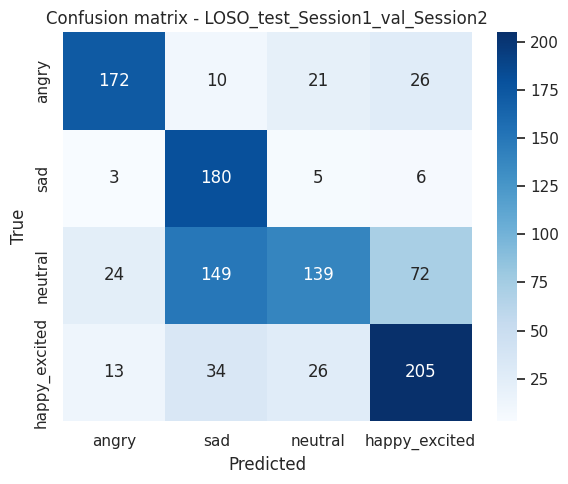

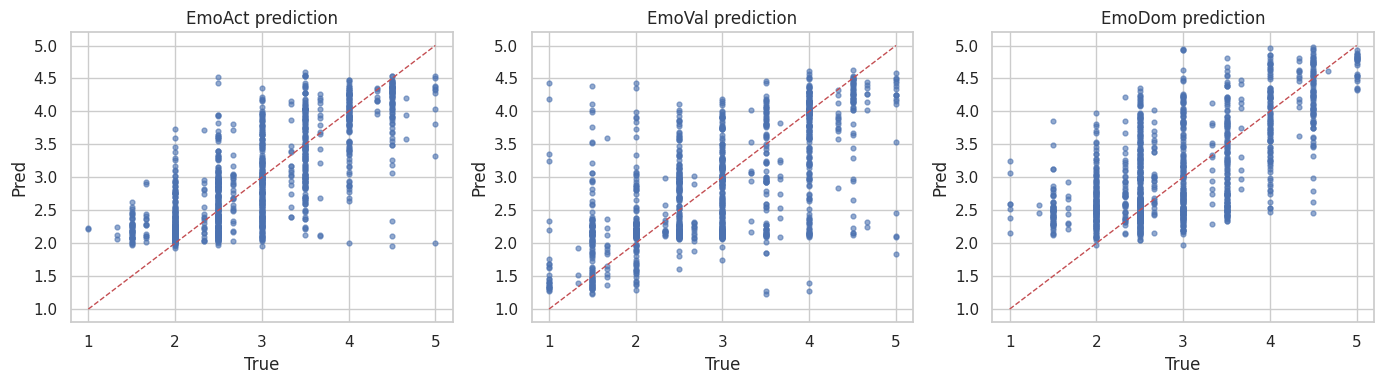

In [18]:
if all_predictions:
    fold_name = list(all_predictions.keys())[0]
    pred = all_predictions[fold_name]
    cm = confusion_matrix(pred["y_true_cls"], pred["y_pred_cls"], labels=list(range(len(COMMON_EMOTIONS))))
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=COMMON_EMOTIONS, yticklabels=COMMON_EMOTIONS)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion matrix - {fold_name}")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"confusion_matrix_{fold_name}.png", dpi=180)
    plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for j, col in enumerate(AVD_COLS):
        axes[j].scatter(pred["avd_true"][:, j], pred["avd_pred"][:, j], s=12, alpha=0.6)
        axes[j].plot([1, 5], [1, 5], "r--", linewidth=1)
        axes[j].set_title(f"{col} prediction")
        axes[j].set_xlabel("True")
        axes[j].set_ylabel("Pred")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"avd_scatter_{fold_name}.png", dpi=180)
    plt.show()


## 15. Reference comparison table

In [19]:
reference_rows = [
    {
        "model": "emotion2vec linear",
        "speaker_independent": "Yes",
        "split": "LOSO 5-fold / LOSpeaker reported",
        "input": "audio -> emotion2vec embedding",
        "emotion_labels": "angry, sad, neutral, happy+excited",
        "reported": "WA around 71.79-72.94; starred variants 74.48-77.64",
        "AVD": "not reported",
    },
    {
        "model": "CA-MSER",
        "speaker_independent": "Yes",
        "split": "LOSO / leave-one-speaker-out",
        "input": "MFCC + spectrogram + wav2vec2 embedding",
        "emotion_labels": "angry, sad, neutral, happy+excited",
        "reported": "LOSO WA/UA 69.80/71.05; LOSpeaker WA/UA 71.64/72.70",
        "AVD": "not reported",
    },
    {
        "model": "FT-w2v2 P-TAPT",
        "speaker_independent": "Yes",
        "split": "LOSO 5-fold",
        "input": "raw waveform",
        "emotion_labels": "4-class emotion",
        "reported": "UA 74.3",
        "AVD": "not reported",
    },
    {
        "model": "DST",
        "speaker_independent": "Yes",
        "split": "LOSO 5-fold",
        "input": "WavLM features",
        "emotion_labels": "4-class emotion",
        "reported": "WA 71.8, UA 73.6",
        "AVD": "not reported",
    },
    {
        "model": "preCPC AVD",
        "speaker_independent": "Yes",
        "split": "IEMOCAP 5-fold CV",
        "input": "raw audio / CPC features",
        "emotion_labels": "N/A",
        "reported": "CCC avg 0.731; act 0.752; val 0.752; dom 0.691",
        "AVD": "continuous activation, valence, dominance",
    },
    {
        "model": "07 proposed multi-task 06D",
        "speaker_independent": "Yes",
        "split": "LOSO 5-fold / optional LOSpeaker 10-fold",
        "input": "emotion2vec + MFCC/log-Mel/statistical acoustic features",
        "emotion_labels": ", ".join(COMMON_EMOTIONS),
        "reported": "to measure in this notebook",
        "AVD": "EmoAct, EmoVal, EmoDom with CCC/MAE/RMSE",
    },
]
reference_df = pd.DataFrame(reference_rows)
display(reference_df)
reference_df.to_csv(REPORT_DIR / "reference_comparison_table.csv", index=False, encoding="utf-8-sig")


,model,speaker_independent,split,input,emotion_labels,reported,AVD
0,emotion2vec linear,Yes,LOSO 5-fold / LOSpeaker reported,audio -> emotion2vec embedding,"angry, sad, neutral, happy+excited",WA around 71.79-72.94; starred variants 74.48-...,not reported
1,CA-MSER,Yes,LOSO / leave-one-speaker-out,MFCC + spectrogram + wav2vec2 embedding,"angry, sad, neutral, happy+excited",LOSO WA/UA 69.80/71.05; LOSpeaker WA/UA 71.64/...,not reported
2,FT-w2v2 P-TAPT,Yes,LOSO 5-fold,raw waveform,4-class emotion,UA 74.3,not reported
3,DST,Yes,LOSO 5-fold,WavLM features,4-class emotion,"WA 71.8, UA 73.6",not reported
4,preCPC AVD,Yes,IEMOCAP 5-fold CV,raw audio / CPC features,N/A,CCC avg 0.731; act 0.752; val 0.752; dom 0.691,"continuous activation, valence, dominance"
5,07 proposed multi-task 06D,Yes,LOSO 5-fold / optional LOSpeaker 10-fold,emotion2vec + MFCC/log-Mel/statistical acousti...,"angry, sad, neutral, happy_excited",to measure in this notebook,"EmoAct, EmoVal, EmoDom with CCC/MAE/RMSE"


## 16. Gợi ý report

Khi viết report:

- Không dùng random split làm kết quả chính.
- Ghi rõ IEMOCAP 4-class setup: `angry`, `sad`, `neutral`, `happy+excited`.
- Classification báo cáo WA/UA/Macro-F1/confusion matrix.
- AVD regression báo cáo CCC/MAE/RMSE cho `EmoAct`, `EmoVal`, `EmoDom`.
- Nếu chưa chạy được Emotion2Vec thật, ghi rõ đang dùng zero embedding/debug và không dùng kết quả đó làm final benchmark.
